# String Match Benchmark: Regex vs Native Polars Operations

Comparing the performance of regex-based string matching (as used in the pandas `StringMatchNode`)
against native Polars string expressions (`.str.contains(literal=True)`, `.str.starts_with()`, `.str.ends_with()`, `==`) across all match types and for varying numbers of patterns in a set.


## 1. Imports and Setup

In [2]:
import time
import timeit
import typing as t
import re
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

print(f"polars version: {pl.__version__}")

# ── Benchmark helper ──────────────────────────────────────────────────────────

def bench(fn: t.Callable, n_runs: int = 20) -> float:
    """Run fn n_runs times and return the mean elapsed time in milliseconds."""
    # warm-up
    fn()
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        fn()
        times.append((time.perf_counter() - t0) * 1_000)
    return float(np.mean(times))

N_RUNS = 20          # benchmark repetitions per case
print(f"N_RUNS = {N_RUNS}")


polars version: 1.37.0
N_RUNS = 20


## 2. Generate Test Data

In [3]:
N_ROWS = 1_000_000   # adjust to taste

rng = np.random.default_rng(42)

# A realistic pool of string values:
#   - some that will match our patterns (mix of match types)
#   - some that definitely won't
_pool = [
    # exact-match targets
    "approved", "declined", "pending", "review",
    # starts-with targets
    "pre_approved", "pre_declined", "prefix_xyz",
    # ends-with targets
    "approved_final", "review_end", "xyz_suffix",
    # contains targets
    "is_approved_now", "under_review_today",
    # noise
    "unknown", "other", "n/a", "", "APPROVED", "Pending",
    "some_long_string_that_matches_nothing_useful",
    "another_noise_value_123", "foo", "bar", "baz",
]

indices = rng.integers(0, len(_pool), size=N_ROWS)
df = pl.DataFrame({"feature": [_pool[i] for i in indices]})

print(f"DataFrame shape: {df.shape}")
print(df["feature"].value_counts().sort("count", descending=True))


DataFrame shape: (1000000, 1)
shape: (23, 2)
┌────────────────────┬───────┐
│ feature            ┆ count │
│ ---                ┆ ---   │
│ str                ┆ u32   │
╞════════════════════╪═══════╡
│ pending            ┆ 43873 │
│ xyz_suffix         ┆ 43832 │
│ n/a                ┆ 43826 │
│ pre_declined       ┆ 43697 │
│ under_review_today ┆ 43669 │
│ …                  ┆ …     │
│ approved           ┆ 43328 │
│ pre_approved       ┆ 43308 │
│                    ┆ 43264 │
│ foo                ┆ 43167 │
│ is_approved_now    ┆ 43161 │
└────────────────────┴───────┘


## 3. Define Pattern Helpers

Re-implementing the regex preprocessors from `StringMatchNode` alongside their native Polars equivalents.


In [4]:
# ── Regex preprocessors (ported from StringMatchNode) ────────────────────────

def regex_exact(val: str) -> str:
    return f"^{re.escape(val)}$"

def regex_contains(val: str) -> str:
    return f"^.*{re.escape(val)}.*$"

def regex_starts_with(val: str) -> str:
    return f"^{re.escape(val)}.*$"

def regex_ends_with(val: str) -> str:
    return f"^.*{re.escape(val)}$"

def join_patterns(patterns: t.List[str], preproc) -> str:
    """Join multiple pre-processed patterns into a single alternation regex."""
    return "|".join(f"(?:{preproc(p)})" for p in patterns)


# ── Native Polars expression builders ─────────────────────────────────────────

def native_exact_single(col: pl.Expr, val: str) -> pl.Expr:
    return col == pl.lit(val)

def native_contains_single(col: pl.Expr, val: str) -> pl.Expr:
    return col.str.contains(val, literal=True)

def native_starts_with_single(col: pl.Expr, val: str) -> pl.Expr:
    return col.str.starts_with(val)

def native_ends_with_single(col: pl.Expr, val: str) -> pl.Expr:
    return col.str.ends_with(val)

def native_exact_multi(col: pl.Expr, vals: t.List[str]) -> pl.Expr:
    return col.is_in(vals)

def native_contains_multi(col: pl.Expr, vals: t.List[str]) -> pl.Expr:
    exprs = [col.str.contains(v, literal=True) for v in vals]
    return exprs[0] if len(exprs) == 1 else pl.fold(exprs[0], lambda a, b: a | b, exprs[1:])

def native_starts_with_multi(col: pl.Expr, vals: t.List[str]) -> pl.Expr:
    exprs = [col.str.starts_with(v) for v in vals]
    return exprs[0] if len(exprs) == 1 else pl.fold(exprs[0], lambda a, b: a | b, exprs[1:])

def native_ends_with_multi(col: pl.Expr, vals: t.List[str]) -> pl.Expr:
    exprs = [col.str.ends_with(v) for v in vals]
    return exprs[0] if len(exprs) == 1 else pl.fold(exprs[0], lambda a, b: a | b, exprs[1:])


print("Helpers defined.")


Helpers defined.


## 4. Benchmark: `exact` — Regex vs `==`

In [7]:
PATTERN_EXACT = "approved"
col = pl.col("feature")

regex_expr   = col.str.contains(regex_exact(PATTERN_EXACT), literal=False)
native_expr  = native_exact_single(col, PATTERN_EXACT)

# Verify equivalence
result_regex  = df.select(regex_expr.alias("match")).get_column("match")
result_native = df.select(native_expr.alias("match")).get_column("match")
assert result_regex.equals(result_native), "Results differ!"
print(f"Match count (both): {result_regex.sum():,}  ✓")

t_regex  = bench(lambda: df.select(col.str.contains(regex_exact(PATTERN_EXACT), literal=False)))
t_native = bench(lambda: df.select(native_exact_single(col, PATTERN_EXACT)))

print(f"\nexact — regex : {t_regex:.2f} ms")
print(f"exact — native: {t_native:.2f} ms")
print(f"speedup       : {t_regex / t_native:.2f}x")

results_single = {"exact": {"regex": t_regex, "native": t_native}}


Match count (both): 43,328  ✓

exact — regex : 12.19 ms
exact — native: 0.91 ms
speedup       : 13.36x


## 5. Benchmark: `contains` — Regex vs `str.contains(literal=True)`

In [8]:
PATTERN_CONTAINS = "approved"

result_regex  = df.select(col.str.contains(regex_contains(PATTERN_CONTAINS), literal=False).alias("m")).get_column("m")
result_native = df.select(native_contains_single(col, PATTERN_CONTAINS).alias("m")).get_column("m")
assert result_regex.equals(result_native), "Results differ!"
print(f"Match count (both): {result_regex.sum():,}  ✓")

t_regex  = bench(lambda: df.select(col.str.contains(regex_contains(PATTERN_CONTAINS), literal=False)))
t_native = bench(lambda: df.select(native_contains_single(col, PATTERN_CONTAINS)))

print(f"\ncontains — regex : {t_regex:.2f} ms")
print(f"contains — native: {t_native:.2f} ms")
print(f"speedup          : {t_regex / t_native:.2f}x")

results_single["contains"] = {"regex": t_regex, "native": t_native}


Match count (both): 173,250  ✓

contains — regex : 25.50 ms
contains — native: 19.01 ms
speedup          : 1.34x


## 6. Benchmark: `starts_with` — Regex vs `str.starts_with`

In [9]:
PATTERN_STARTS = "pre_"

result_regex  = df.select(col.str.contains(regex_starts_with(PATTERN_STARTS), literal=False).alias("m")).get_column("m")
result_native = df.select(native_starts_with_single(col, PATTERN_STARTS).alias("m")).get_column("m")
assert result_regex.equals(result_native), "Results differ!"
print(f"Match count (both): {result_regex.sum():,}  ✓")

t_regex  = bench(lambda: df.select(col.str.contains(regex_starts_with(PATTERN_STARTS), literal=False)))
t_native = bench(lambda: df.select(native_starts_with_single(col, PATTERN_STARTS)))

print(f"\nstarts_with — regex : {t_regex:.2f} ms")
print(f"starts_with — native: {t_native:.2f} ms")
print(f"speedup             : {t_regex / t_native:.2f}x")

results_single["starts_with"] = {"regex": t_regex, "native": t_native}


Match count (both): 87,005  ✓

starts_with — regex : 19.28 ms
starts_with — native: 6.67 ms
speedup             : 2.89x


## 7. Benchmark: `ends_with` — Regex vs `str.ends_with`

In [11]:
PATTERN_ENDS = "_end"

result_regex  = df.select(col.str.contains(regex_ends_with(PATTERN_ENDS), literal=False).alias("m")).get_column("m")
result_native = df.select(native_ends_with_single(col, PATTERN_ENDS).alias("m")).get_column("m")
assert result_regex.equals(result_native), "Results differ!"
print(f"Match count (both): {result_regex.sum():,}  ✓")

t_regex  = bench(lambda: df.select(col.str.contains(regex_ends_with(PATTERN_ENDS), literal=False)))
t_native = bench(lambda: df.select(native_ends_with_single(col, PATTERN_ENDS)))

print(f"\nends_with — regex : {t_regex:.2f} ms")
print(f"ends_with — native: {t_native:.2f} ms")
print(f"speedup           : {t_regex / t_native:.2f}x")

results_single["ends_with"] = {"regex": t_regex, "native": t_native}


Match count (both): 43,389  ✓

ends_with — regex : 28.40 ms
ends_with — native: 6.53 ms
speedup           : 4.35x


## 8. Benchmark: Multi-pattern Set — Pipe-joined Regex vs Chained Native Expressions

Testing across pattern counts of 1, 2, 5, 10, 20 to see how each approach scales.


In [12]:
# Pattern bank — draw the first N patterns from this list for each experiment
_PATTERN_BANK = [
    "approved", "declined", "pending", "review",
    "pre_approved", "pre_declined", "prefix_xyz",
    "approved_final", "review_end", "xyz_suffix",
    "is_approved_now", "under_review_today",
    "unknown", "other", "n/a", "foo", "bar", "baz", "qux", "quux",
]

PATTERN_COUNTS = [1, 2, 5, 10, 20]

# match_type → (regex_preproc, native_multi_fn)
MULTI_VARIANTS: t.Dict[str, t.Tuple[t.Callable, t.Callable]] = {
    "exact":       (regex_exact,       native_exact_multi),
    "contains":    (regex_contains,    native_contains_multi),
    "starts_with": (regex_starts_with, native_starts_with_multi),
    "ends_with":   (regex_ends_with,   native_ends_with_multi),
}

results_multi: t.Dict[str, t.Dict[int, t.Dict[str, float]]] = {k: {} for k in MULTI_VARIANTS}

for match_type, (preproc, native_fn) in MULTI_VARIANTS.items():
    print(f"\n── {match_type} ──")
    for n in PATTERN_COUNTS:
        patterns = _PATTERN_BANK[:n]
        regex_pat = join_patterns(patterns, preproc)

        # Verify equivalence at n=1
        if n == 1:
            r_regex  = df.select(col.str.contains(regex_pat, literal=False).alias("m")).get_column("m")
            r_native = df.select(native_fn(col, patterns).alias("m")).get_column("m")
            assert r_regex.equals(r_native), f"Mismatch for {match_type} n={n}"

        t_regex  = bench(lambda rp=regex_pat:   df.select(col.str.contains(rp, literal=False)))
        t_native = bench(lambda ps=patterns:    df.select(native_fn(col, ps)))

        results_multi[match_type][n] = {"regex": t_regex, "native": t_native}
        print(f"  n={n:>2}: regex={t_regex:6.2f} ms  native={t_native:6.2f} ms  speedup={t_regex/t_native:.2f}x")



── exact ──
  n= 1: regex= 12.13 ms  native= 12.69 ms  speedup=0.96x
  n= 2: regex= 12.31 ms  native= 13.54 ms  speedup=0.91x
  n= 5: regex= 21.11 ms  native= 17.45 ms  speedup=1.21x
  n=10: regex= 21.13 ms  native= 18.17 ms  speedup=1.16x
  n=20: regex= 26.75 ms  native= 18.79 ms  speedup=1.42x

── contains ──
  n= 1: regex= 25.43 ms  native= 19.03 ms  speedup=1.34x
  n= 2: regex= 24.77 ms  native= 19.01 ms  speedup=1.30x
  n= 5: regex= 29.84 ms  native= 23.46 ms  speedup=1.27x
  n=10: regex= 28.98 ms  native= 28.61 ms  speedup=1.01x
  n=20: regex= 32.67 ms  native= 44.47 ms  speedup=0.73x

── starts_with ──
  n= 1: regex= 17.69 ms  native=  7.14 ms  speedup=2.48x
  n= 2: regex= 18.40 ms  native=  7.42 ms  speedup=2.48x
  n= 5: regex= 25.25 ms  native=  8.60 ms  speedup=2.94x
  n=10: regex= 24.18 ms  native= 11.12 ms  speedup=2.17x
  n=20: regex= 28.04 ms  native= 17.20 ms  speedup=1.63x

── ends_with ──
  n= 1: regex= 25.26 ms  native=  7.15 ms  speedup=3.53x
  n= 2: regex= 24.45 ms

## 9. Results Visualization

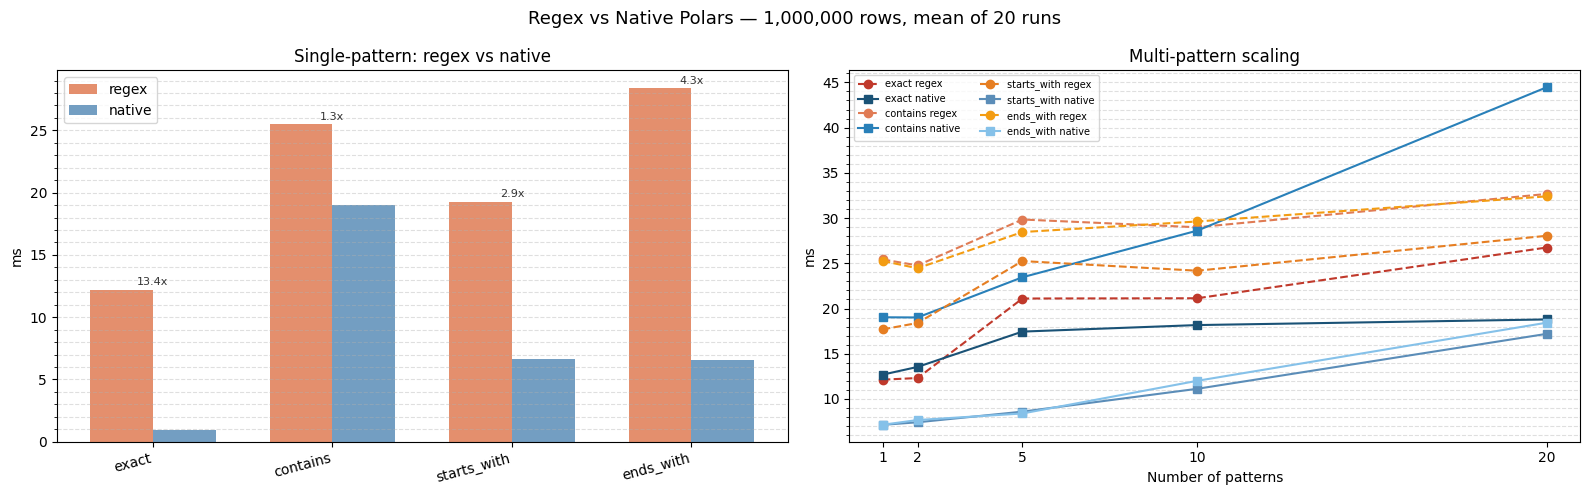

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f"Regex vs Native Polars — {N_ROWS:,} rows, mean of {N_RUNS} runs", fontsize=13)

# ── Plot 1: single-pattern grouped bar chart ──────────────────────────────────
ax1 = axes[0]
match_types = list(results_single.keys())
x = np.arange(len(match_types))
width = 0.35

bars_regex  = [results_single[k]["regex"]  for k in match_types]
bars_native = [results_single[k]["native"] for k in match_types]

ax1.bar(x - width/2, bars_regex,  width, label="regex",  color="#e07b54", alpha=0.85)
ax1.bar(x + width/2, bars_native, width, label="native", color="#5b8db8", alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(match_types, rotation=15, ha="right")
ax1.set_ylabel("ms")
ax1.set_title("Single-pattern: regex vs native")
ax1.legend()
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.grid(axis="y", which="both", linestyle="--", alpha=0.4)

# Annotate speedup
for xi, (r, n) in enumerate(zip(bars_regex, bars_native)):
    ax1.text(xi, max(r, n) + 0.2, f"{r/n:.1f}x", ha="center", va="bottom", fontsize=8, color="#333")

# ── Plot 2: multi-pattern scaling line chart ──────────────────────────────────
ax2 = axes[1]
colors_regex  = ["#c0392b", "#e07b54", "#e67e22", "#f39c12"]
colors_native = ["#1a5276", "#2980b9", "#5b8db8", "#85c1e9"]

for i, (match_type, color_r, color_n) in enumerate(zip(MULTI_VARIANTS, colors_regex, colors_native)):
    ns      = sorted(results_multi[match_type].keys())
    t_regs  = [results_multi[match_type][n]["regex"]  for n in ns]
    t_nats  = [results_multi[match_type][n]["native"] for n in ns]
    ax2.plot(ns, t_regs,  "o--", color=color_r, label=f"{match_type} regex",  linewidth=1.5)
    ax2.plot(ns, t_nats,  "s-",  color=color_n, label=f"{match_type} native", linewidth=1.5)

ax2.set_xlabel("Number of patterns")
ax2.set_ylabel("ms")
ax2.set_title("Multi-pattern scaling")
ax2.legend(fontsize=7, ncol=2)
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax2.grid(axis="y", which="both", linestyle="--", alpha=0.4)
ax2.set_xticks(PATTERN_COUNTS)

plt.tight_layout()
plt.show()


In [14]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for mt, v in results_single.items():
    rows.append({"match_type": mt, "n_patterns": 1, "regex_ms": round(v["regex"], 3), "native_ms": round(v["native"], 3)})

for mt, counts in results_multi.items():
    for n, v in counts.items():
        rows.append({"match_type": mt, "n_patterns": n, "regex_ms": round(v["regex"], 3), "native_ms": round(v["native"], 3)})

summary = (
    pl.DataFrame(rows)
    .with_columns((pl.col("regex_ms") / pl.col("native_ms")).round(2).alias("speedup"))
    .sort(["match_type", "n_patterns"])
)
print(summary)


shape: (24, 5)
┌─────────────┬────────────┬──────────┬───────────┬─────────┐
│ match_type  ┆ n_patterns ┆ regex_ms ┆ native_ms ┆ speedup │
│ ---         ┆ ---        ┆ ---      ┆ ---       ┆ ---     │
│ str         ┆ i64        ┆ f64      ┆ f64       ┆ f64     │
╞═════════════╪════════════╪══════════╪═══════════╪═════════╡
│ contains    ┆ 1          ┆ 25.502   ┆ 19.014    ┆ 1.34    │
│ contains    ┆ 1          ┆ 25.426   ┆ 19.032    ┆ 1.34    │
│ contains    ┆ 2          ┆ 24.767   ┆ 19.011    ┆ 1.3     │
│ contains    ┆ 5          ┆ 29.841   ┆ 23.456    ┆ 1.27    │
│ contains    ┆ 10         ┆ 28.984   ┆ 28.612    ┆ 1.01    │
│ …           ┆ …          ┆ …        ┆ …         ┆ …       │
│ starts_with ┆ 1          ┆ 19.276   ┆ 6.672     ┆ 2.89    │
│ starts_with ┆ 2          ┆ 18.402   ┆ 7.422     ┆ 2.48    │
│ starts_with ┆ 5          ┆ 25.246   ┆ 8.598     ┆ 2.94    │
│ starts_with ┆ 10         ┆ 24.18    ┆ 11.124    ┆ 2.17    │
│ starts_with ┆ 20         ┆ 28.042   ┆ 17.2      ┆ 1.6

## Sanity Check: Case-insensitive Matching

In [15]:
_ci_df = pl.DataFrame({"s": ["Approved", "APPROVED", "approved", "declined", "DECLINED", "Pending", "HELLO"]})
pat = "approved"

checks = {
    # exact: lowercase feature + is_in
    "exact (insensitive)":
        _ci_df.select(_ci_df["s"].str.to_lowercase().is_in([pat]).alias("match"))["match"].to_list(),
    # contains: lowercase feature + literal contains
    "contains (insensitive)":
        _ci_df.select(_ci_df["s"].str.to_lowercase().str.contains(pat, literal=True).alias("match"))["match"].to_list(),
    # starts_with: lowercase feature + str.starts_with
    "starts_with (insensitive)":
        _ci_df.select(_ci_df["s"].str.to_lowercase().str.starts_with(pat).alias("match"))["match"].to_list(),
    # regex with (?i) flag
    "regex (?i) contains":
        _ci_df.select(_ci_df["s"].str.contains(f"(?i){re.escape(pat)}", literal=False).alias("match"))["match"].to_list(),
}

for label, matches in checks.items():
    hits = [v for v, m in zip(_ci_df["s"].to_list(), matches) if m]
    print(f"{label:<30} → matched: {hits}")


exact (insensitive)            → matched: ['Approved', 'APPROVED', 'approved']
contains (insensitive)         → matched: ['Approved', 'APPROVED', 'approved']
starts_with (insensitive)      → matched: ['Approved', 'APPROVED', 'approved']
regex (?i) contains            → matched: ['Approved', 'APPROVED', 'approved']
